#### Simple Perceptron

Predictions: [0 0 0 1]


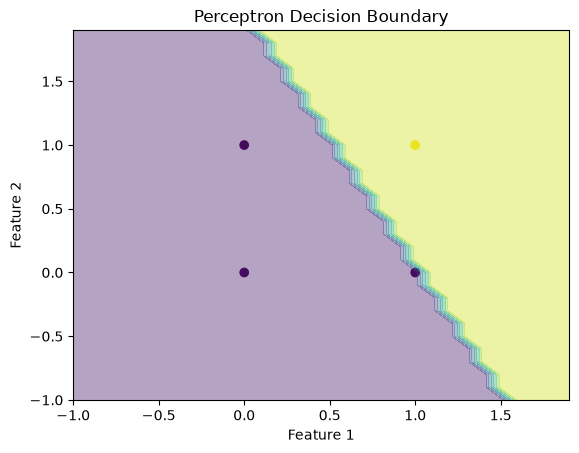

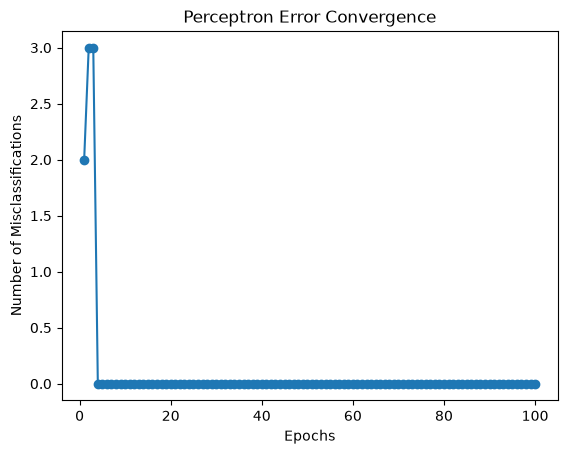

Final weights: [0.2 0.1]
Final bias: -0.20000000000000004


In [2]:
import numpy as np
import matplotlib.pyplot as plt

class Perceptron:
    def __init__(self, learning_rate=0.01, n_iters=1000):
        self.learning_rate = learning_rate
        self.n_iters = n_iters
        self.weights = None
        self.bias = None
        self.errors = []
    
    def fit(self, X, y):
        n_features = X.shape[1]
        self.weights = np.zeros(n_features)
        self.bias = 0
        self.errors = []
        for _ in range(self.n_iters):
            errors = 0
            for idx, x_i in enumerate(X):
                linear_output = np.dot(x_i, self.weights) + self.bias
                y_predicted = self.activation_function(linear_output)
                # Perceptron update rule
                update = self.learning_rate * (y[idx] - y_predicted)
                self.weights += update * x_i
                self.bias += update
                errors += int(update != 0.0)
            self.errors.append(errors)
                
    def activation_function(self, x):
        return np.where(x >= 0, 1, 0)
    
    def predict(self, X):
        linear_output = np.dot(X, self.weights) + self.bias
        return self.activation_function(linear_output)
    
    def plot_decision_boundary(self, X, y):
        plt.scatter(X[:, 0], X[:, 1], c=y, cmap='viridis')
        x1_min, x1_max = X[:, 0].min() - 1, X[:, 0].max() + 1
        x2_min, x2_max = X[:, 1].min() - 1, X[:, 1].max() + 1
        xx1, xx2 = np.meshgrid(np.arange(x1_min, x1_max, 0.1), np.arange(x2_min, x2_max, 0.1))    
        Z = self.predict(np.c_[xx1.ravel(), xx2.ravel()])
        Z = Z.reshape(xx1.shape)
        plt.contourf(xx1, xx2, Z, alpha=0.4, cmap="viridis")
        plt.xlabel("Feature 1")
        plt.ylabel("Feature 2")
        plt.title("Perceptron Decision Boundary")
    
# Example data: AND logic gate
X = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])
y = np.array([0, 0, 0, 1])  # AND logic output

# Create and train Perceptron
perceptron = Perceptron(learning_rate=0.1, n_iters=100)
perceptron.fit(X, y)

# Test the Perceptron
predictions = perceptron.predict(X)
print(f"Predictions: {predictions}")

# Plot decision boundary
perceptron.plot_decision_boundary(X, y)
plt.show()

# Plot error convergence
plt.plot(range(1, len(perceptron.errors) + 1), perceptron.errors, marker="o")
plt.xlabel("Epochs")
plt.ylabel("Number of Misclassifications")
plt.title("Perceptron Error Convergence")
plt.show()

# Print final weights and bias
print(f"Final weights: {perceptron.weights}")
print(f"Final bias: {perceptron.bias}")